In [16]:
import os
import rasterio
import numpy as np
from PIL import Image
import ee
import geemap
import random
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

In [ ]:
def converter_dataset(pasta_origem, pasta_destino, eh_mascara=False):
    os.makedirs(pasta_destino, exist_ok=True)
    arquivos = [f for f in os.listdir(pasta_origem) if f.endswith('.tif')]
    
    print(f"Convertendo {len(arquivos)} arquivos de {pasta_origem}...")

    for arquivo in arquivos:
        caminho_in = os.path.join(pasta_origem, arquivo)
        caminho_out = os.path.join(pasta_destino, arquivo)

        with rasterio.open(caminho_in) as src:
            profile = src.profile

            # =========================
            # MÁSCARAS
            # =========================
            if eh_mascara:
                data = src.read(1).astype(np.uint8)

                profile.update(
                    dtype=rasterio.uint8,
                    count=1
                )

                with rasterio.open(caminho_out, 'w', **profile) as dst:
                    dst.write(data, 1)

            # =========================
            # IMAGENS (MULTIBANDA)
            # =========================
            else:
                data = src.read().astype(np.float32)  # ✅ MANTÉM PRECISÃO

                profile.update(
                    dtype=rasterio.float32,
                    count=data.shape[0]
                )

                with rasterio.open(caminho_out, 'w', **profile) as dst:
                    dst.write(data)

converter_dataset(
    'dataset_tif/images',
    'dataset/images',
    eh_mascara=False
)

converter_dataset(
    'dataset_tif/masks',
    'dataset/masks',
    eh_mascara=True
)

Convertendo 100 arquivos de dataset_tif/images...


C:\Users\danie\AppData\Local\Temp\ipykernel_11268\3555293474.py:34: RuntimeWarning: invalid value encountered in cast
  data_norm[i] = np.clip(


Convertendo 100 arquivos de dataset_tif/masks...


In [2]:
#===================================
# 2 PistasDatase
#==================================

class PistasDataset(Dataset):
    def __init__(self, image_dir, mask_dir, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(image, (256, 256))
        mask = TF.resize(mask, (256, 256))
        
        # Converte UMA vez
        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        
        if self.augment:
            k = random.choice([0, 1, 2, 3])
            image = torch.rot90(image, k, [1, 2])
            mask = torch.rot90(mask, k, [1, 2])
        
            if random.random() > 0.5:
                image = torch.flip(image, [2])
                mask = torch.flip(mask, [2])
            
            if random.random() > 0.5:
                image = torch.flip(image, [1])
                mask = torch.flip(mask, [1])
        
        mask = (mask > 0.5).float()
        
        return image, mask


def get_doubled_dataset(img_dir, mask_dir):
    dataset_original = PistasDataset(img_dir, mask_dir, augment=False)
    
    dataset_aumentado = PistasDataset(img_dir, mask_dir, augment=True)
    
    dataset_final = ConcatDataset([dataset_original, dataset_aumentado])
    
    return dataset_final


In [3]:
#===================================
# 3: preparação do dataloader
#==================================

full_dataset = get_doubled_dataset('dataset/images', 'dataset/masks')

# 2. Divida o dataset COMPLETO em treino e validação
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# random_split garantirá que amostras originais e suas versões aumentadas 
# sejam distribuídas aleatoriamente
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Dados de treino: {len(train_dataset)}, dados de validação: {len(val_dataset)}")

Dados de treino: 128, dados de validação: 32


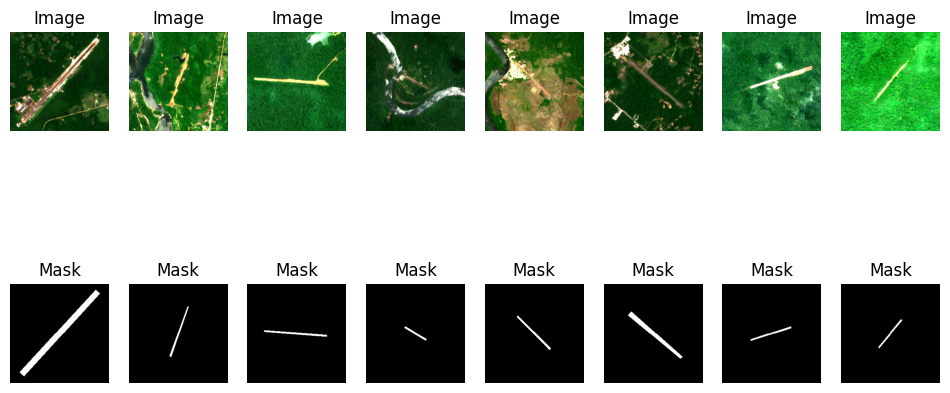

In [4]:
#===================================
# Mostrar 1 batch
#==================================

images, masks = next(iter(train_loader))

plt.figure(figsize=(12,6))
for i in range(len(images)):
    plt.subplot(2, len(images), i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2, len(images), i+1+len(images))
    plt.imshow(masks[i].squeeze(), cmap="gray")
    plt.title("Mask")
    plt.axis("off")

In [5]:
#===================================
# 4: Construir modelo u-net
#==================================
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
        
        self.name = "Classical U-net"
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.conv_last = nn.Conv2d(64, 1, kernel_size=1)
    
    def forward(self, x):
        c1 = self.enc1(x)
        p1 = self.pool(c1)

        c2 = self.enc2(p1)
        p2 = self.pool(c2)

        c3 = self.enc3(p2)
        p3 = self.pool(c3)

        c4 = self.enc4(p3)
        p4 = self.pool(c4)

        bottleneck = self.bottleneck(p4)

        u4 = self.upconv4(bottleneck)
        u4 = torch.cat([u4, c4], dim=1)
        d4 = self.dec4(u4)

        u3 = self.upconv3(d4)
        u3 = torch.cat([u3, c3], dim=1)
        d3 = self.dec3(u3)

        u2 = self.upconv2(d3)
        u2 = torch.cat([u2, c2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.upconv1(d2)
        u1 = torch.cat([u1, c1], dim=1)
        d1 = self.dec1(u1)

        return torch.sigmoid(self.conv_last(d1))




In [9]:
#===================================
# 4: Construir modelo res unet
#==================================

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        
        # Caminho de Convolução (As caixas verdes da sua imagem)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        
        # Atalho (A seta preta curva da sua imagem)
        # Se os canais de entrada forem diferentes da saída (ex: 3 -> 64), 
        # uma Conv 1x1 para ajustar as dimensões antes de somar.
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out += self.shortcut(residual) # O sinal de "+" da sua imagem (Residual Connection)
        out = self.relu(out)
        return out

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        
        # Encoder - Usando o novo ResidualBlock
        self.name = "Residual U-net"
        self.enc1 = ResidualBlock(3, 64)
        self.enc2 = ResidualBlock(64, 128)
        self.enc3 = ResidualBlock(128, 256)
        self.enc4 = ResidualBlock(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ResidualBlock(512, 1024)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = ResidualBlock(1024, 512) # Recebe 512 (up) + 512 (skip) = 1024

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ResidualBlock(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ResidualBlock(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ResidualBlock(128, 64)

        self.conv_last = nn.Conv2d(64, 1, kernel_size=1)
    
    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool(c1)

        c2 = self.enc2(p1)
        p2 = self.pool(c2)

        c3 = self.enc3(p2)
        p3 = self.pool(c3)

        c4 = self.enc4(p3)
        p4 = self.pool(c4)

        # Bottleneck
        bn = self.bottleneck(p4)

        # Decoder com Skip Connections (U-Net style concatenation)
        u4 = self.upconv4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        d4 = self.dec4(u4)

        u3 = self.upconv3(d4)
        u3 = torch.cat([u3, c3], dim=1)
        d3 = self.dec3(u3)

        u2 = self.upconv2(d3)
        u2 = torch.cat([u2, c2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.upconv1(d2)
        u1 = torch.cat([u1, c1], dim=1)
        d1 = self.dec1(u1)

        # Saída final (Binary Segmentation)
        return torch.sigmoid(self.conv_last(d1))

In [26]:
#===================================
# 4: Construir modelo attention unet
#==================================

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()

        #W_g: processa o decoder ex:(64x64) -> 64x64
        self.w_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=False), 
            nn.BatchNorm2d(F_int)
            )

        #w_x: Processo o decoder ex: 128x128 -> 64x64, com stride 2
        self.w_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        #psi vai colapsar os canais
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1,stride=1, padding=0, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # g: [Batch, F_g, 64, 64], exemplo
        # x: [Batch, F_l, 128, 128], exemplo

        g1 = self.w_g(g)
        x1 = self.w_x(x)

        if x1.shape[2:] != g1.shape[2:]:
            x1 = F.interpolate(x1, size=g1.shape[2:], mode='bilinear', align_corners=True)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        alpha = F.interpolate(psi, size=x.shape[2:], mode='bilinear', align_corners=True)

        return x * alpha

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
        
        self.name = "Attention U-net"
        
        # Encoder
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = conv_block(512, 1024)

        # Decoder + Attention Gates
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att4 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.dec4 = conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.dec3 = conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.dec2 = conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=64, F_l=64, F_int=32) 
        self.dec1 = conv_block(128, 64)

        self.conv_last = nn.Conv2d(64, 1, kernel_size=1)
    
    def forward(self, x):
        # Encoder Path
        c1 = self.enc1(x)
        p1 = self.pool(c1)

        c2 = self.enc2(p1)
        p2 = self.pool(c2)

        c3 = self.enc3(p2)
        p3 = self.pool(c3)

        c4 = self.enc4(p3)
        p4 = self.pool(c4)

        # Bottleneck
        bn = self.bottleneck(p4)

        # Decoder Path com Attention Gates
        u4 = self.upconv4(bn)
        s4 = self.att4(g=u4, x=c4) 
        d4 = self.dec4(torch.cat([u4, s4], dim=1))

        u3 = self.upconv3(d4)
        s3 = self.att3(g=u3, x=c3)
        d3 = self.dec3(torch.cat([u3, s3], dim=1))

        u2 = self.upconv2(d3)
        s2 = self.att2(g=u2, x=c2)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.upconv1(d2)
        s1 = self.att1(g=u1, x=c1)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return torch.sigmoid(self.conv_last(d1))

In [ ]:
#===================================
# 5: Setup de treino
#==================================

class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.bce = nn.BCELoss()
        self.smooth = smooth
        self.name = "BCEDiceLoss"

    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)

        # BCE
        bce = self.bce(pred, target)

        # Dice
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        dice_loss = 1 - dice

        return bce + 2 * dice_loss


In [ ]:
#===================================
# 5: Setup de treino
#==================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = UNet().to(device)
print(model.name)
#criterion = nn.BCELoss()
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print(device)
model = UNet().to(device)
print(model.name)
#criterion = nn.BCELoss()
criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

cuda
Attention U-net


In [ ]:
#===================================
# 6: Loop de treino
#==================================

num_epochs = 150

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    val_loss = 0
    model.eval()
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")
    
print(f"Epoca {epoch+1}/{num_epochs}, perda treino: {train_loss/len(train_loader)}, Val Loss: {val_loss/len(val_loader):.4f}, Modelo name: {model.name}")

Epoch 1/150 | Train Loss: 0.9485 | Val Loss: 0.9692


In [ ]:
#===================================

# 7: vizualizar predições aleatórias

#==================================
os.makedirs("predicoes_attUnet_diceloss_150", exist_ok=True)

model.eval()

for i in range(len(val_dataset)):
    img, mask = val_dataset[i]
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img)

    img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
    mask_np = mask.squeeze().cpu().numpy()
    pred_np = pred.squeeze().cpu().numpy()

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("GT")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Pred")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"predicoes_attUnet_diceloss_150/img_{i}.png")
    plt.close()


In [ ]:
#Salva Modelo
# Salvar modelo
caminho_modelo = "res_attUnet_pistas_belem_150ep.pth"

# Salvando os pesos
torch.save(model.state_dict(), caminho_modelo)

In [ ]:
ee.Initialize(project="desafio-solved")

municipios = ee.FeatureCollection("FAO/GAUL/2015/level2")

lista_municipios = [
    'Altamira', 'Anapu', 'Brasil Novo', 'Medicilandia',
    'Pacaja', 'Senador Jose Porfirio', 'Uruara', 'Vitoria do Xingu',
    'Itaituba', 'Aveiro', 'Jacareacanga', 'Novo Progresso',
    'Ruropolis', 'Trairao'
]

sudoeste = municipios.filter(ee.Filter.inList("ADM2_NAME", lista_municipios))

roi = sudoeste.geometry()

colecao = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2023-01-01', '2023-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

imagem = colecao.median().clip(roi)

mapa = geemap.Map()
mapa.centerObject(roi, 7)

mapa.addLayer(imagem, {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}, 'Sudoeste do Pará')

mapa


NameError: name 'ee' is not defined